# Gradient Boosting for Credit Default Prediction

This project applies Gradient Boosting to predict credit-card default using the UCI Default of Credit Card Clients dataset.

The analysis focuses on three questions:

1. How well can Gradient Boosting discriminate between defaulting and non-defaulting clients?
2. Does a nonlinear tree-based model outperform a simpler Logistic Regression benchmark?
3. Which variables contribute most strongly to out-of-sample predictive performance?

Because the default class represents only about 22% of observations, model evaluation emphasizes ROC-AUC and precision-recall metrics rather than accuracy alone.

In [1]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

credit = fetch_ucirepo(id=350)

X = credit.data.features
y = credit.data.targets.squeeze()

X.head(), y.head()

(       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X14    X15    X16  \
 0   20000   2   2   1  24   2   2  -1  -1   -2  ...    689      0      0   
 1  120000   2   2   2  26  -1   2   0   0    0  ...   2682   3272   3455   
 2   90000   2   2   2  34   0   0   0   0    0  ...  13559  14331  14948   
 3   50000   2   2   1  37   0   0   0   0    0  ...  49291  28314  28959   
 4   50000   1   2   1  57  -1   0  -1   0    0  ...  35835  20940  19146   
 
      X17   X18    X19    X20   X21   X22   X23  
 0      0     0    689      0     0     0     0  
 1   3261     0   1000   1000  1000     0  2000  
 2  15549  1518   1500   1000  1000  1000  5000  
 3  29547  2000   2019   1200  1100  1069  1000  
 4  19131  2000  36681  10000  9000   689   679  
 
 [5 rows x 23 columns],
 0    1
 1    1
 2    0
 3    0
 4    0
 Name: Y, dtype: int64)

## 1. Data Exploration

The dataset contains 30,000 credit-card clients and 23 explanatory variables covering credit limits, demographic characteristics, repayment history, bill balances, and previous payments.

The target variable indicates whether a client defaulted in the following month.

I first inspect the feature structure, missing values, descriptive statistics, and target distribution.

In [3]:
X.shape

(30000, 23)

In [4]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   X1      30000 non-null  int64
 1   X2      30000 non-null  int64
 2   X3      30000 non-null  int64
 3   X4      30000 non-null  int64
 4   X5      30000 non-null  int64
 5   X6      30000 non-null  int64
 6   X7      30000 non-null  int64
 7   X8      30000 non-null  int64
 8   X9      30000 non-null  int64
 9   X10     30000 non-null  int64
 10  X11     30000 non-null  int64
 11  X12     30000 non-null  int64
 12  X13     30000 non-null  int64
 13  X14     30000 non-null  int64
 14  X15     30000 non-null  int64
 15  X16     30000 non-null  int64
 16  X17     30000 non-null  int64
 17  X18     30000 non-null  int64
 18  X19     30000 non-null  int64
 19  X20     30000 non-null  int64
 20  X21     30000 non-null  int64
 21  X22     30000 non-null  int64
 22  X23     30000 non-null  int64
dtypes: int64(23

In [5]:
y.value_counts()

Y
0    23364
1     6636
Name: count, dtype: int64

In [6]:
y.value_counts(normalize=True)

Y
0    0.7788
1    0.2212
Name: proportion, dtype: float64

In [7]:
X.columns

Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11',
       'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21',
       'X22', 'X23'],
      dtype='object')

In [8]:
X.describe().T

,count,mean,std,min,25%,50%,75%,max
X1,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
X2,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
X3,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
X4,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
X5,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
X6,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
X7,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
X8,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
X9,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0
X10,30000.0,-0.266200,1.133187,-2.0,-1.00,0.0,0.00,8.0


## 2. Feature Cleaning and Encoding

The original dataset labels explanatory variables as `X1` to `X23`. These are renamed to reflect their economic meaning.

Several variables are integer-coded categorical features rather than continuous quantities. Rare or undocumented education and marital-status codes are consolidated into an `Other` category, while repayment-status variables retain their original ordinal encoding.

In [9]:
X = X.rename(columns={
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6",
})

In [10]:
X.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


In [11]:
for col in ["SEX", "EDUCATION", "MARRIAGE",
            "PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]:
    print(col)
    print(X[col].value_counts().sort_index())
    print()

SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

MARRIAGE
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    1694

In [12]:
X["EDUCATION"] = X["EDUCATION"].replace({
    0: 4,
    5: 4,
    6: 4
})

X["MARRIAGE"] = X["MARRIAGE"].replace({
    0: 3
})

In [13]:
X["EDUCATION"].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

In [14]:
X["MARRIAGE"].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

## 3. Train-Test Split and Baseline

The data are split into training and test sets using stratification so that the default rate remains approximately constant across both samples.

Because only about 22% of clients default, a majority-class classifier can achieve nearly 78% accuracy without possessing any discriminatory power. A Dummy Classifier is therefore used to establish a baseline, while ROC-AUC and PR-AUC are treated as more informative evaluation metrics.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
print("Training set:")
print(y_train.value_counts(normalize=True))

print("\nTest set:")
print(y_test.value_counts(normalize=True))

Training set:
Y
0    0.778792
1    0.221208
Name: proportion, dtype: float64

Test set:
Y
0    0.778833
1    0.221167
Name: proportion, dtype: float64


In [17]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, average_precision_score

dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)
dummy_prob = dummy.predict_proba(X_test)[:, 1]

print("Dummy accuracy:", accuracy_score(y_test, dummy_pred))
print("Dummy ROC-AUC:", roc_auc_score(y_test, dummy_prob))
print("Dummy PR-AUC:", average_precision_score(y_test, dummy_prob))

Dummy accuracy: 0.7788333333333334
Dummy ROC-AUC: 0.5
Dummy PR-AUC: 0.22116666666666668


## 4. Gradient Boosting Model

A Gradient Boosting classifier is first fitted using the default scikit-learn specification.

The model is evaluated using accuracy, ROC-AUC, average precision, precision, recall, and F1 score. Particular attention is paid to recall because false negatives correspond to defaulting clients being classified as non-defaulting.

In [18]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]

In [19]:
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

print("Gradient Boosting accuracy:",
      accuracy_score(y_test, gb_pred))

print("Gradient Boosting ROC-AUC:",
      roc_auc_score(y_test, gb_prob))

print("Gradient Boosting PR-AUC:",
      average_precision_score(y_test, gb_prob))

print("Precision:",
      precision_score(y_test, gb_pred))

print("Recall:",
      recall_score(y_test, gb_pred))

print("F1:",
      f1_score(y_test, gb_pred))

Gradient Boosting accuracy: 0.8185
Gradient Boosting ROC-AUC: 0.7789576187726283
Gradient Boosting PR-AUC: 0.5526058492738422
Precision: 0.6657381615598886
Recall: 0.3602110022607385
F1: 0.46748166259168705


In [20]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, gb_pred)

array([[4433,  240],
       [ 849,  478]])

## 5. Hyperparameter Selection

Model complexity is explored using five-fold cross-validation over learning rate, tree depth, and number of estimators.

ROC-AUC is used as the cross-validation objective because it evaluates the model's ability to rank default risk independently of a particular classification threshold.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [1, 2, 3]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", grid.best_score_)

Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Best CV ROC-AUC: 0.7816198728477615


In [22]:
best_gb = grid.best_estimator_

best_prob = best_gb.predict_proba(X_test)[:, 1]
best_pred = best_gb.predict(X_test)

print("Test ROC-AUC:", roc_auc_score(y_test, best_prob))
print("Test PR-AUC:", average_precision_score(y_test, best_prob))
print("Test accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred))
print("Recall:", recall_score(y_test, best_pred))
print("F1:", f1_score(y_test, best_pred))

Test ROC-AUC: 0.77663044012881
Test PR-AUC: 0.5519690287287788
Test accuracy: 0.8176666666666667
Precision: 0.6620305980528511
Recall: 0.35870384325546345
F1: 0.46529814271749753


Since hyperparameter tuning did not improve held-out performance, the default Gradient Boosting model is retained for the final comparison.

## 6. Model Interpretation

Permutation importance measures how much test-set ROC-AUC deteriorates when each feature is randomly shuffled.

Unlike built-in tree importance, this directly measures the contribution of each variable to out-of-sample predictive performance.

In [23]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    gb,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.Series(
    perm.importances_mean,
    index=X_test.columns
).sort_values(ascending=False)

perm_importance.head(10)

PAY_0        0.076834
BILL_AMT1    0.015343
LIMIT_BAL    0.014209
PAY_2        0.006650
PAY_3        0.004488
PAY_AMT3     0.004320
PAY_AMT2     0.003593
PAY_AMT1     0.003361
BILL_AMT2    0.003138
PAY_4        0.002662
dtype: float64

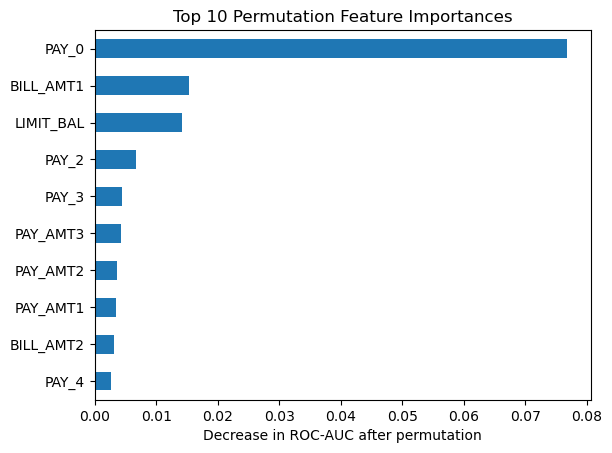

In [24]:
import matplotlib.pyplot as plt

perm_importance.head(10).sort_values().plot(kind="barh")
plt.xlabel("Decrease in ROC-AUC after permutation")
plt.title("Top 10 Permutation Feature Importances")
plt.show()

The most recent repayment status (`PAY_0`) is by far the most influential individual feature. Credit limit and the most recent bill balance also contribute meaningfully, while earlier repayment and payment variables provide smaller incremental improvements.

These results describe predictive importance rather than causal effects.

## 7. Logistic Regression Benchmark

To assess whether nonlinear modelling adds predictive value, Gradient Boosting is compared with Logistic Regression.

Continuous and ordinal variables are standardized, while nominal categorical variables are one-hot encoded. This provides a simpler and more interpretable linear benchmark using the same training and test observations.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

categorical_features = ["SEX", "EDUCATION", "MARRIAGE"]

numeric_features = [
    col for col in X.columns
    if col not in categorical_features
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"),
         categorical_features)
    ]
)

logit = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logit.fit(X_train, y_train)

logit_prob = logit.predict_proba(X_test)[:, 1]
logit_pred = logit.predict(X_test)

In [26]:
print("Logistic Regression accuracy:",
      accuracy_score(y_test, logit_pred))

print("Logistic Regression ROC-AUC:",
      roc_auc_score(y_test, logit_prob))

print("Logistic Regression PR-AUC:",
      average_precision_score(y_test, logit_prob))

print("Precision:",
      precision_score(y_test, logit_pred))

print("Recall:",
      recall_score(y_test, logit_pred))

print("F1:",
      f1_score(y_test, logit_pred))

Logistic Regression accuracy: 0.8088333333333333
Logistic Regression ROC-AUC: 0.7100908859130948
Logistic Regression PR-AUC: 0.4950469951876558
Precision: 0.6923076923076923
Recall: 0.24415975885455915
F1: 0.36100278551532033


## 8. Model Comparison

The three models are compared using accuracy, ROC-AUC, PR-AUC, precision, recall, and F1 score.

The ROC curve evaluates ranking performance across classification thresholds, while the precision-recall curve is particularly informative because the default class is moderately imbalanced.

In [27]:
results = pd.DataFrame({
    "Model": [
        "Dummy Classifier",
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, dummy_pred),
        accuracy_score(y_test, logit_pred),
        accuracy_score(y_test, gb_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, dummy_prob),
        roc_auc_score(y_test, logit_prob),
        roc_auc_score(y_test, gb_prob)
    ],
    "PR-AUC": [
        average_precision_score(y_test, dummy_prob),
        average_precision_score(y_test, logit_prob),
        average_precision_score(y_test, gb_prob)
    ],
    "Precision": [
        precision_score(y_test, dummy_pred, zero_division=0),
        precision_score(y_test, logit_pred),
        precision_score(y_test, gb_pred)
    ],
    "Recall": [
        recall_score(y_test, dummy_pred),
        recall_score(y_test, logit_pred),
        recall_score(y_test, gb_pred)
    ],
    "F1": [
        f1_score(y_test, dummy_pred),
        f1_score(y_test, logit_pred),
        f1_score(y_test, gb_pred)
    ]
})

results.round(3)

,Model,Accuracy,ROC-AUC,PR-AUC,Precision,Recall,F1
0,Dummy Classifier,0.779,0.500,0.221,0.000,0.000,0.000
1,Logistic Regression,0.809,0.710,0.495,0.692,0.244,0.361
2,Gradient Boosting,0.818,0.779,0.553,0.666,0.360,0.467


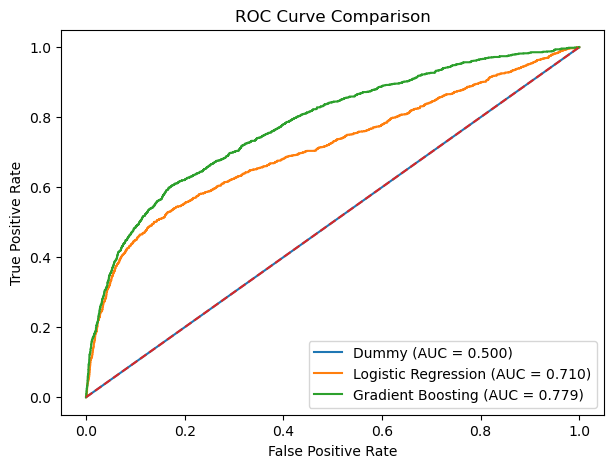

In [28]:
from sklearn.metrics import roc_curve

fpr_dummy, tpr_dummy, _ = roc_curve(y_test, dummy_prob)
fpr_logit, tpr_logit, _ = roc_curve(y_test, logit_prob)
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(7, 5))

plt.plot(fpr_dummy, tpr_dummy,
         label="Dummy (AUC = 0.500)")

plt.plot(fpr_logit, tpr_logit,
         label=f"Logistic Regression (AUC = {roc_auc_score(y_test, logit_prob):.3f})")

plt.plot(fpr_gb, tpr_gb,
         label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, gb_prob):.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

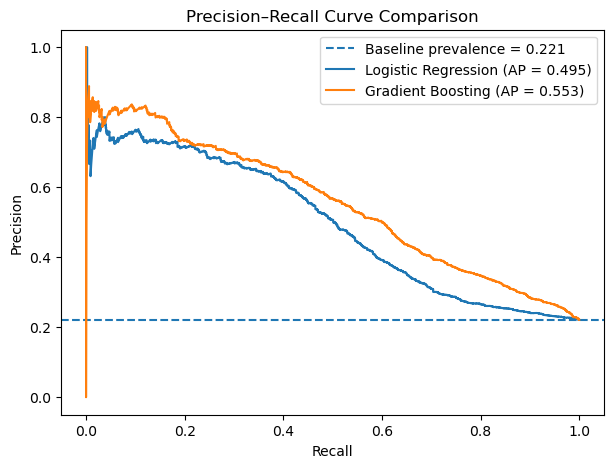

In [29]:
from sklearn.metrics import precision_recall_curve

precision_logit, recall_logit, _ = precision_recall_curve(
    y_test, logit_prob
)

precision_gb, recall_gb, _ = precision_recall_curve(
    y_test, gb_prob
)

baseline = y_test.mean()

plt.figure(figsize=(7, 5))

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Baseline prevalence = {baseline:.3f}"
)

plt.plot(
    recall_logit,
    precision_logit,
    label=f"Logistic Regression (AP = {average_precision_score(y_test, logit_prob):.3f})"
)

plt.plot(
    recall_gb,
    precision_gb,
    label=f"Gradient Boosting (AP = {average_precision_score(y_test, gb_prob):.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison")
plt.legend()
plt.show()

## 9. Conclusion

Gradient Boosting provided the strongest overall discrimination of credit-default risk, achieving a test ROC-AUC of approximately 0.779 and a PR-AUC of 0.553.

It materially outperformed Logistic Regression, particularly in recall and F1 score, indicating that nonlinear relationships and feature interactions contain useful predictive information beyond a linear benchmark.

The majority-class baseline also illustrates why accuracy alone is misleading in this setting: a model with no discriminatory ability achieved nearly 78% accuracy because non-default observations dominate the sample.

Permutation importance identified recent repayment status as the strongest predictor, followed by credit limit and recent bill balance.

Hyperparameter tuning produced little improvement over the default Gradient Boosting specification, suggesting that the main performance gains arose from the model class itself rather than extensive parameter optimization.

Overall, the project demonstrates the importance of appropriate benchmarking, evaluation under class imbalance, and model interpretation when applying machine-learning methods to credit-risk classification.